In [1]:
import sys
sys.path.append("/data/kcchan_rec/ding_post_mess/jupyter_mess/aureum")

import wx_iter_funcs as wif

import numpy as np

In [2]:
from glob import glob

base_dir_new = "/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod"

prod_dict_pkl_list= sorted(glob(f"{base_dir_new}/**/prod_dict*.pkl", recursive=True))

print(prod_dict_pkl_list)

['/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std0p145875/posi/prod_dict_N100_bin100.pkl', '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std0p145875/posi/prod_dict_N100_bin100_wdg.pkl', '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std0p145875/posi/prod_dict_N100_bin200.pkl', '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std0p145875/posi/prod_dict_N100_bin200_wdg.pkl', '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std0p145875/posi/prod_dict_N200_bin100.pkl', '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std0p145875/posi/prod_dict_N200_bin100_wdg.pkl', '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std

In [3]:
prod_dict = wif.read_pickle_any(prod_dict_pkl_list[3])

Reading pickle file 
 ---> '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_std0p145875/posi/prod_dict_N100_bin200_wdg.pkl' <---

FUNC: <read_pickle_any>  TIME: 0.17s



In [4]:
import re, copy, io, contextlib

avg_pkl_list = []
avg_labels  = []

for gp in range(0, len(prod_dict_pkl_list), 16):
    for j in range(8):
        with contextlib.redirect_stdout(io.StringIO()):
            lo = wif.read_pickle_any(prod_dict_pkl_list[gp + j])
            hi = wif.read_pickle_any(prod_dict_pkl_list[gp + 8 + j])
        avg = {}
        for k in lo:
            avg[k] = ((lo[k].astype(float) + hi[k].astype(float)) / 2.0
                      if isinstance(lo[k], np.ndarray) else copy.deepcopy(lo[k]))
        avg_pkl_list.append(avg)
        label = re.sub(r'std\d+p\d+', 'avg', prod_dict_pkl_list[gp + j])
        avg_labels.append(label)

print("avg_pkl_list = [")
for i, lbl in enumerate(avg_labels):
    print(f"  [{i:2d}]  {repr(lbl)},")
print("]")
print(f"原始 {len(prod_dict_pkl_list)} → 平均后 {len(avg_pkl_list)}")

avg_pkl_list = [
  [ 0]  '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_avg/posi/prod_dict_N100_bin100.pkl',
  [ 1]  '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_avg/posi/prod_dict_N100_bin100_wdg.pkl',
  [ 2]  '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_avg/posi/prod_dict_N100_bin200.pkl',
  [ 3]  '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_avg/posi/prod_dict_N100_bin200_wdg.pkl',
  [ 4]  '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_avg/posi/prod_dict_N200_bin100.pkl',
  [ 5]  '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L3000_N1024_fNL0_Z0p5110_avg/posi/prod_dict_N200_bin100_wdg.pkl',
  [ 6]  '/mnt/loong/Raid6/2/luantch/checkpoint/mess_out/202511/HKL_noise_direct_prod/L300

In [5]:
import numpy as np

# 沿 axis=0（100 个实现方向）计算方差，结果 shape=(200, 200)
tf_var = np.var(prod_dict["tf_2d_bin_all"], axis=0)

# 查看结果
import re

print("tf_2d_bin_all 按红移分组：")
for gp in range(0, len(avg_pkl_list), 8):
    # 提取红移标签
    z_match = re.search(r'Z(\d+p\d+)', avg_labels[gp])
    z_str = z_match.group(1).replace('p', '.') if z_match else "?"
    print(f"\n{'='*60}")
    print(f"  红移 z = {z_str}")
    print(f"{'='*60}")
    
    for j in range(8):
        idx = gp + j
        d = avg_pkl_list[idx]
        arr = d["tf_2d_bin_all"]
        fname = avg_labels[idx].split('/')[-1]
        print(f"  [{idx:2d}] {fname:<50s}  shape={arr.shape}")

tf_2d_bin_all 按红移分组：

  红移 z = 0.5110
  [ 0] prod_dict_N100_bin100.pkl                           shape=(100, 100, 100)
  [ 1] prod_dict_N100_bin100_wdg.pkl                       shape=(100, 100, 100)
  [ 2] prod_dict_N100_bin200.pkl                           shape=(100, 200, 200)
  [ 3] prod_dict_N100_bin200_wdg.pkl                       shape=(100, 200, 200)
  [ 4] prod_dict_N200_bin100.pkl                           shape=(200, 100, 100)
  [ 5] prod_dict_N200_bin100_wdg.pkl                       shape=(200, 100, 100)
  [ 6] prod_dict_N200_bin200.pkl                           shape=(200, 200, 200)
  [ 7] prod_dict_N200_bin200_wdg.pkl                       shape=(200, 200, 200)

  红移 z = 0.9890
  [ 8] prod_dict_N100_bin100.pkl                           shape=(100, 100, 100)
  [ 9] prod_dict_N100_bin100_wdg.pkl                       shape=(100, 100, 100)
  [10] prod_dict_N100_bin200.pkl                           shape=(100, 200, 200)
  [11] prod_dict_N100_bin200_wdg.pkl                  

In [6]:
def show_dict_structure(d, name="prod_dict"):
    print(f"{name}:")
    for k, v in d.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:18s} -> ndarray, shape={v.shape}, dtype={v.dtype}")
        elif isinstance(v, dict):
            print(f"  {k:18s} -> dict, keys={list(v.keys())}")
        elif isinstance(v, list):
            print(f"  {k:18s} -> list, len={len(v)}")
        elif isinstance(v, tuple):
            print(f"  {k:18s} -> tuple, len={len(v)}")
        else:
            print(f"  {k:18s} -> {type(v).__name__}, value={v}")

In [7]:
show_dict_structure(prod_dict)

prod_dict:
  kcut               -> float, value=0.025
  mask_2d            -> ndarray, shape=(200, 200), dtype=bool
  idx_list           -> list, len=39
  x_idx_arr          -> ndarray, shape=(39,), dtype=int64
  y_idx_arr          -> ndarray, shape=(39,), dtype=int64
  kper_cut           -> ndarray, shape=(39,), dtype=float64
  kpar_cut           -> ndarray, shape=(39,), dtype=float64
  k_cut              -> ndarray, shape=(39,), dtype=float64
  kper_bin           -> ndarray, shape=(200,), dtype=float64
  kpar_bin           -> ndarray, shape=(200,), dtype=float64
  Neff_bin           -> ndarray, shape=(200, 200), dtype=float64
  tf_2d_bin_avg      -> ndarray, shape=(200, 200), dtype=float64
  tf_2d_bin_all      -> ndarray, shape=(100, 200, 200), dtype=float64
  pk_2d_bin_orig     -> ndarray, shape=(200, 200), dtype=float64
  pk_2d_bin_posi_all -> ndarray, shape=(100, 200, 200), dtype=float64
  pk_2d_bin_posi_avg -> ndarray, shape=(200, 200), dtype=float64
  pk_2d_bin_resc_all -> ndarr

In [8]:
import numpy as np
import re

print("=" * 70)
print("tf_fisher_arr = Var(T) / Mean(T)^2  按红移 z 分组")
print("=" * 70)

for gp in range(0, len(avg_pkl_list), 8):
    # 提取红移标签
    z_match = re.search(r'Z(\d+p\d+)', avg_labels[gp])
    z_str = z_match.group(1).replace('p', '.') if z_match else "?"
    
    print(f"\n{'─' * 60}")
    print(f"  红移 z = {z_str}")
    print(f"{'─' * 60}")
    
    for j in range(8):
        idx = gp + j
        d = avg_pkl_list[idx]
        arr = d["tf_2d_bin_all"]                    # shape (100, 200, 200)
        
        var_arr = np.var(arr, axis=0)                # shape (200, 200)
        mean_arr = np.mean(arr, axis=0)              # shape (200, 200)
        fisher_arr = var_arr / (mean_arr ** 2)       # shape (200, 200)
        
        finite = np.isfinite(fisher_arr)
        vals = fisher_arr[finite]
        
        fname = avg_labels[idx].split('/')[-1]
        print(f"  [{idx:3d}] {fname:<48s} | "
              f"min={np.min(vals):.4e}  max={np.max(vals):.4e}  "
              f"median={np.median(vals):.4e}  mean={np.mean(vals):.4e}")

tf_fisher_arr = Var(T) / Mean(T)^2  按红移 z 分组

────────────────────────────────────────────────────────────
  红移 z = 0.5110
────────────────────────────────────────────────────────────
  [  0] prod_dict_N100_bin100.pkl                        | min=1.5650e-05  max=5.1847e-03  median=6.0114e-05  mean=1.5328e-04
  [  1] prod_dict_N100_bin100_wdg.pkl                    | min=1.5685e-05  max=5.3471e-03  median=6.0060e-05  mean=1.5382e-04
  [  2] prod_dict_N100_bin200.pkl                        | min=4.6397e-05  max=5.0880e-02  median=2.5243e-04  mean=7.4117e-04
  [  3] prod_dict_N100_bin200_wdg.pkl                    | min=4.6672e-05  max=5.0764e-02  median=2.5244e-04  mean=7.4209e-04
  [  4] prod_dict_N200_bin100.pkl                        | min=1.8944e-05  max=4.4949e-03  median=6.0394e-05  mean=1.5366e-04
  [  5] prod_dict_N200_bin100_wdg.pkl                    | min=1.8981e-05  max=4.7273e-03  median=6.0377e-05  mean=1.5403e-04
  [  6] prod_dict_N200_bin200.pkl                        | m

In [9]:
# ===== 导出 fisher_arr 供 6.7-interferometer 使用 =====
import joblib
import numpy as np

mock_indices = [7, 15, 23, 31, 39, 47]
lightweight = []

for idx in mock_indices:
    d = avg_pkl_list[idx]
    arr = d["tf_2d_bin_all"].astype(np.float32)      # (100, 200, 200)
    
    var_arr  = np.var(arr, axis=0)                     # Var(T), (200,200)
    mean_arr = np.mean(arr, axis=0)                    # ⟨T⟩,   (200,200)
    fisher   = var_arr / (mean_arr ** 2)               # Var(T)/⟨T⟩², (200,200)
    
    lightweight.append({
        "kper_bin":   d["kper_bin"],
        "kpar_bin":   d["kpar_bin"],
        "fisher_arr": fisher,
    })
    print(f"  [{idx:3d}] z-bin {idx//8} | fisher_arr min={fisher.min():.4e}  max={fisher.max():.4e}  median={np.median(fisher):.4e}")

out_path = "mock_fisher_arr.joblib"
joblib.dump(lightweight, out_path)
print(f"\n已导出 {len(lightweight)} 个红移 bin 到 {out_path}，总大小约 {sum(d['fisher_arr'].nbytes for d in lightweight)/1024**2:.1f} MB")

  [  7] z-bin 0 | fisher_arr min=5.5604e-05  max=4.7276e-02  median=2.5430e-04
  [ 15] z-bin 1 | fisher_arr min=2.2655e-05  max=4.1858e-02  median=1.8053e-04
  [ 23] z-bin 2 | fisher_arr min=1.0574e-05  max=3.9800e-02  median=1.2054e-04
  [ 31] z-bin 3 | fisher_arr min=6.4979e-06  max=3.6570e-02  median=7.9566e-05
  [ 39] z-bin 4 | fisher_arr min=7.0315e-06  max=3.9634e-02  median=7.3892e-05
  [ 47] z-bin 5 | fisher_arr min=4.7128e-06  max=3.4013e-02  median=5.9420e-05

已导出 6 个红移 bin 到 mock_fisher_arr.joblib，总大小约 0.9 MB


In [10]:
tf_raw_arr = prod_dict["tf_2d_bin_all"]

In [11]:
print(tf_raw_arr.shape)

(100, 200, 200)


In [12]:
tf_var_arr = np.var(tf_raw_arr, axis=0)
tf_mean_arr = np.mean(tf_raw_arr, axis=0)

In [13]:
tf_fisher_arr = tf_var_arr / tf_mean_arr**2.

In [14]:
tf_fisher_arr.shape

(200, 200)

In [15]:
tf_fisher_arr[0, :].shape

(200,)

In [16]:
print(type(tf_fisher_arr))

<class 'numpy.ndarray'>


In [17]:
print(tf_fisher_arr[0, 0])

0.0036215417156005344


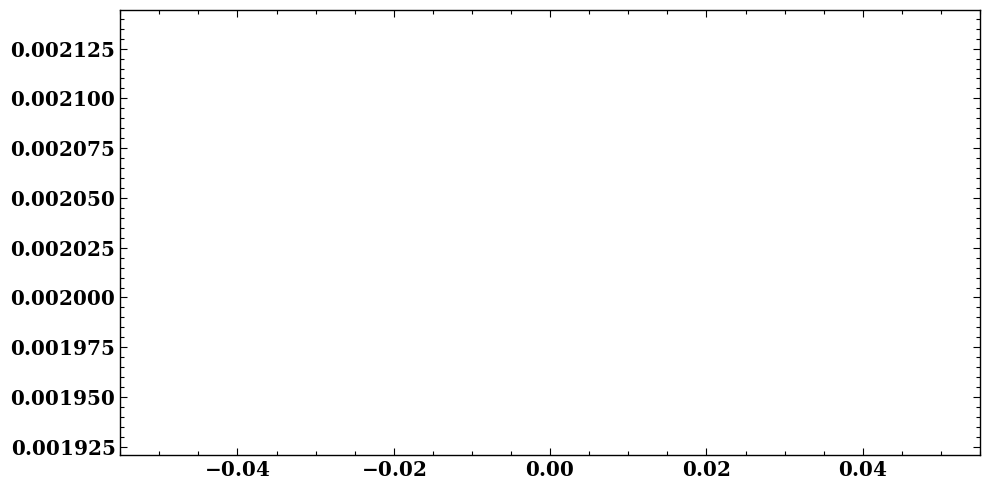

In [18]:
import matplotlib as _mpl
_mpl.rcParams["text.usetex"] = False
import matplotlib.pyplot as plt

plt.plot(tf_fisher_arr[1, 1])

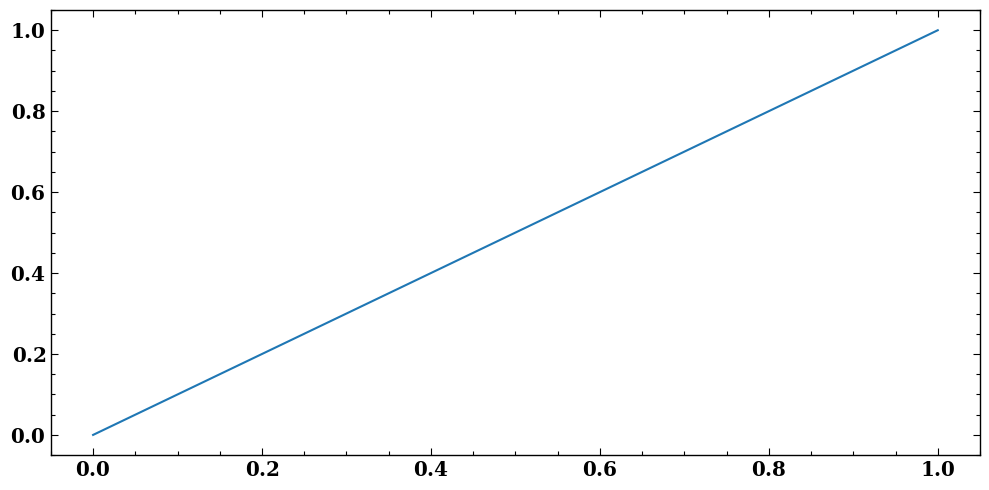

In [19]:
import matplotlib as _mpl
_mpl.rcParams["text.usetex"] = False
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 100)
plt.plot(x, x)

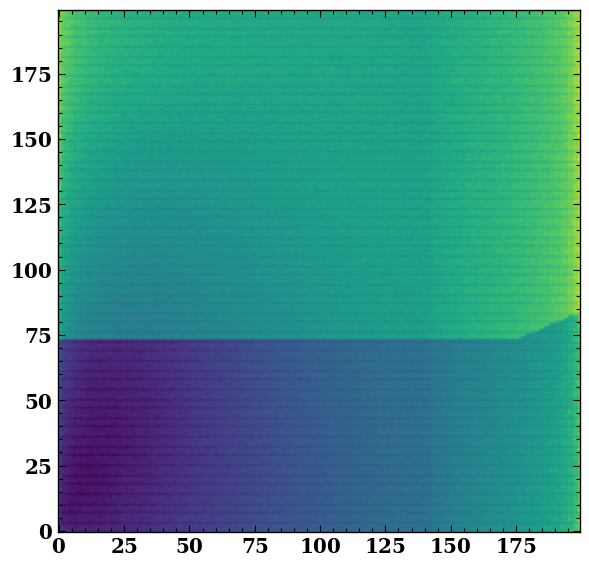

In [20]:
import matplotlib as _mpl
_mpl.rcParams["text.usetex"] = False

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(figsize=(6, 6))
plt.imshow(tf_var_arr.T, cmap='viridis', norm=LogNorm(), origin='lower')
# plt.plot(tf_fisher_arr[0, :])

### Transfer function V

/data/kcchan_rec/ding_post_mess/jupyter_mess/aureum/wx_iter_funcs.py:3372: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


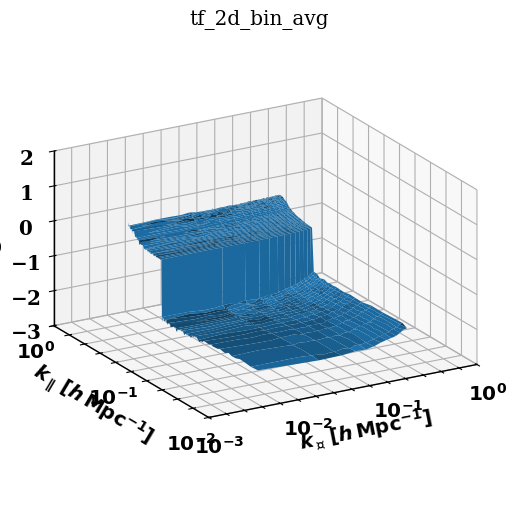

In [21]:
wif.fisher_plotprod_key(prod_dict, "tf_2d_bin_avg",  elev=20, azim=-120);

### Power2d Original V

Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


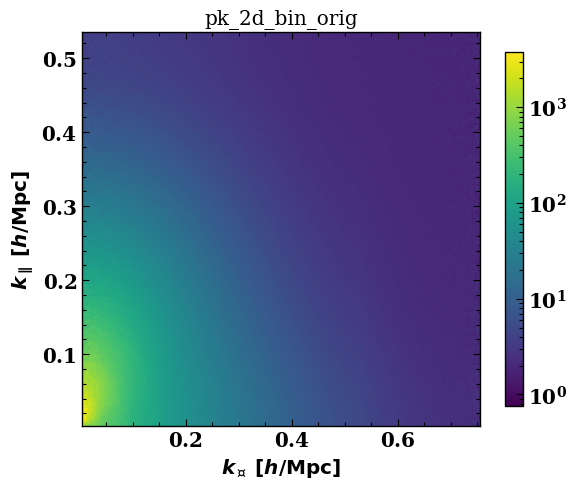

In [22]:
wif.fisher_plotprod_key(prod_dict, "pk_2d_bin_orig", use_log=True);

### Power2d rescaled V

Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


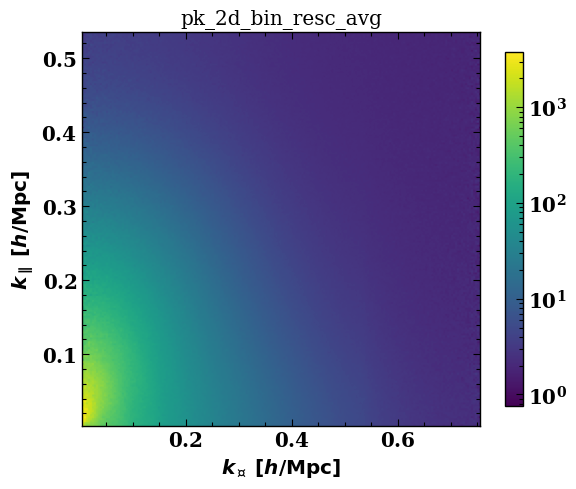

In [23]:
wif.fisher_plotprod_key(prod_dict, "pk_2d_bin_resc_avg", use_log=True);

### Power2d positivized V

Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


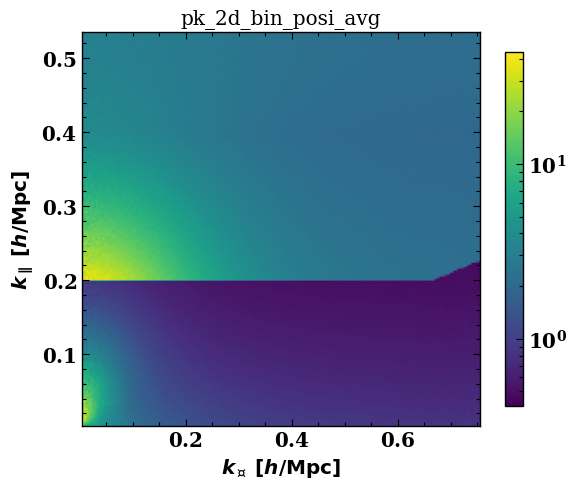

In [24]:
wif.fisher_plotprod_key(prod_dict, "pk_2d_bin_posi_avg", use_log=True);

### rk2d positivized V

Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


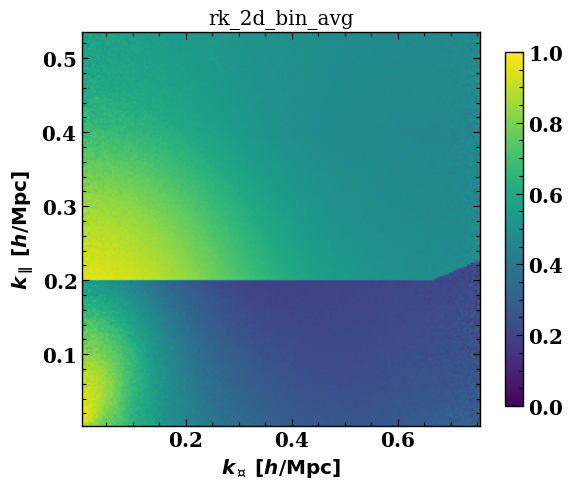

In [25]:
wif.fisher_plotprod_key(prod_dict, "rk_2d_bin_avg", vmin=0, vmax=1);

Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


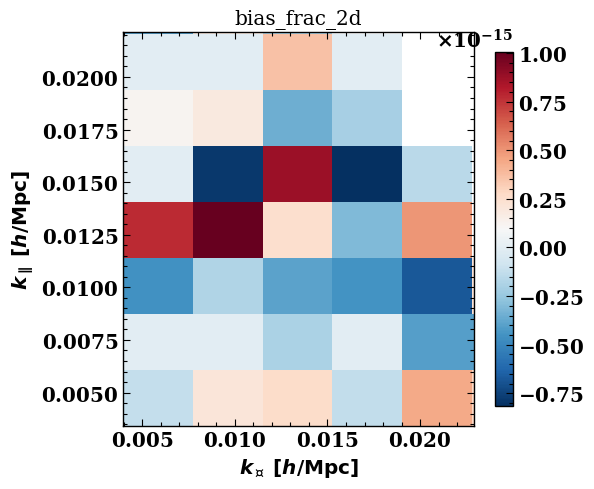

In [26]:
wif.fisher_plotprod_key(prod_dict, "bias_frac_2d", cmap="RdBu_r");

Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


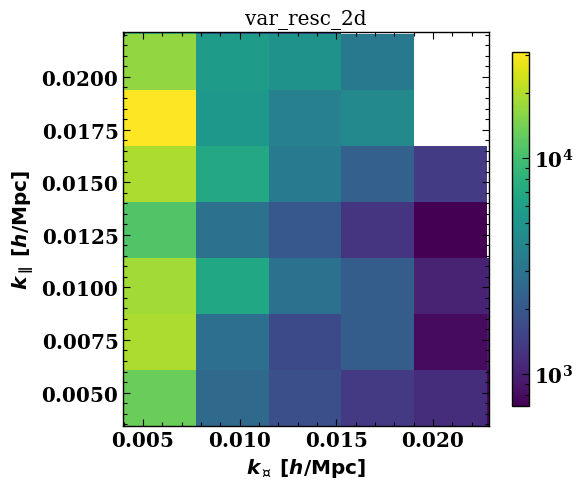

In [27]:
wif.fisher_plotprod_key(prod_dict, "var_resc_2d", use_log=True);

Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\perp' [U+27c2], substituting with a dummy symbol.


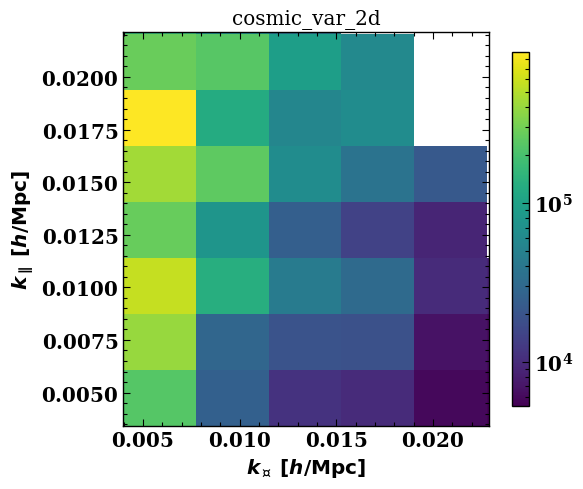

In [28]:
wif.fisher_plotprod_key(prod_dict, "cosmic_var_2d", use_log=True);

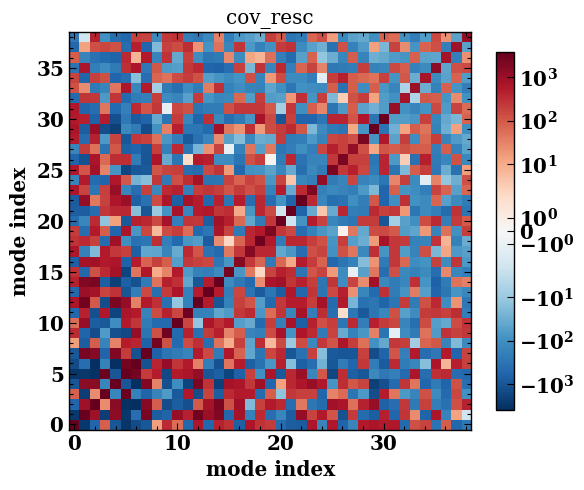

In [29]:
wif.fisher_plotprod_key(prod_dict, "cov_resc", use_symlog=True);

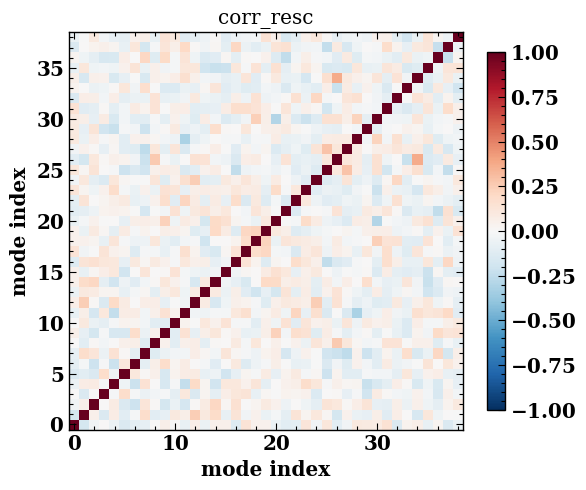

In [30]:
wif.fisher_plotprod_key(prod_dict, "corr_resc", vmin=-1, vmax=1);

Total image number : 6


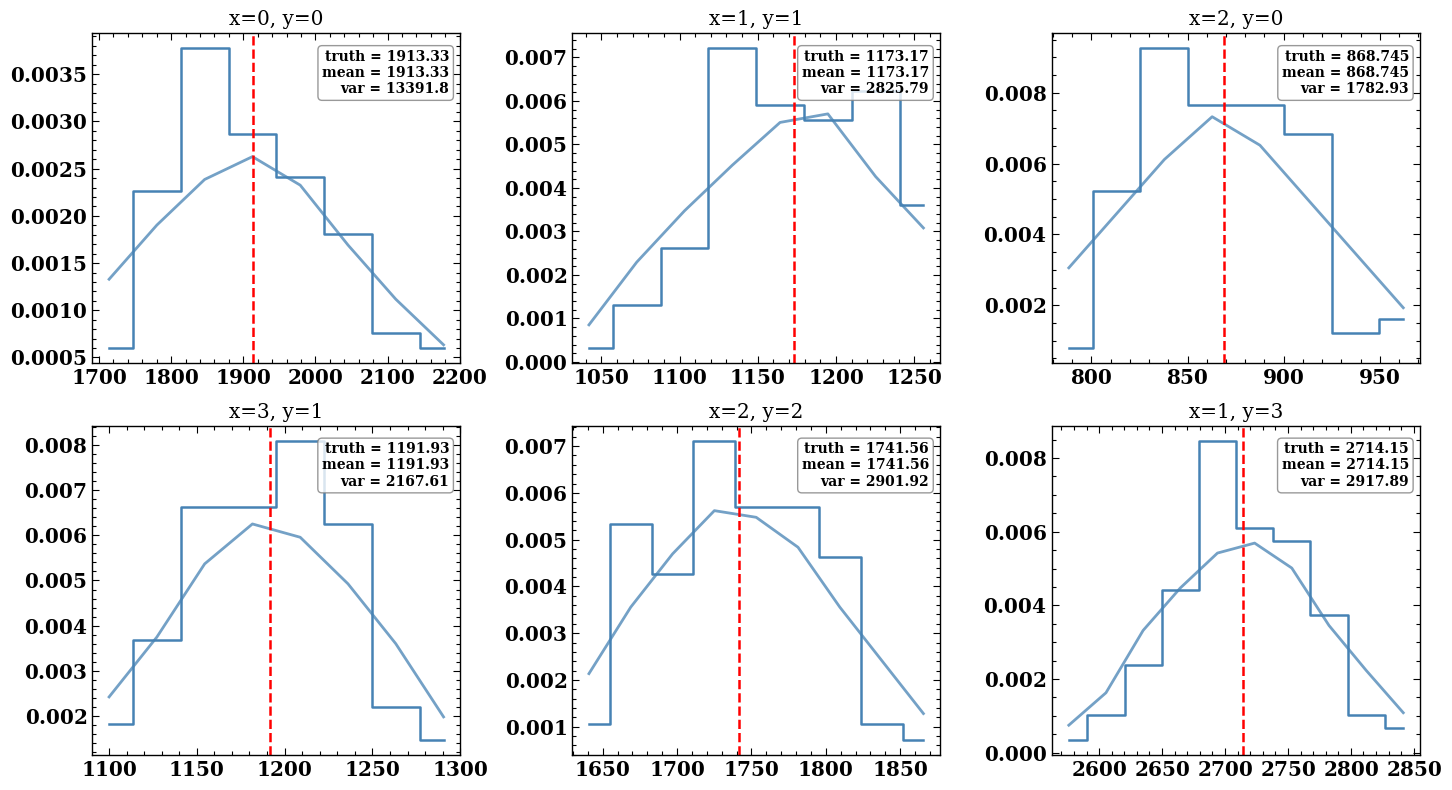

In [31]:
wif.fisher_plotprod_pdf(prod_dict, "pk_2d_bin_resc_all", 
                        [(0, 0), (1, 1), (2, 0), (3, 1), (2, 2), (1, 3)], 
                        truth_key="pk_2d_bin_orig", cols=3);